# 09 — Publication Figures

All figures: Arial, 600 DPI, PDF format, panel labels (a)(b)(c)..., saved to `../figure/`.

| Figure | Content | Data source |
|--------|---------|-------------|
| Graphical Abstract | Programmatic pipeline overview | None (matplotlib patches) |
| Fig 1 | EDA PairGrid (20 variables) | `metal_cleaned.csv` |
| Fig 2 | Model comparison (3-metric bars + 50-split scatter) | `model_selection_results.json`, `repeated_split_results.json`, `plot_phase_b.npz` |
| Fig 3 | SHAP polar rose + top1 dependence | `shap_plot_data.npz`, `shap_plot_meta.json`, `best_models/model_*.pkl` |
| Fig 4 | Inverse design (PCA + Pareto + validation) | `cluster_pareto.csv`, `training_clustered.csv` |

In [4]:
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.patches import (FancyBboxPatch, Rectangle, Circle,
                                FancyArrowPatch, Polygon, Ellipse)
from matplotlib.ticker import AutoMinorLocator
from pathlib import Path
from scipy.spatial.distance import cdist, pdist
warnings.filterwarnings('ignore')

# ── Global style (matching archive/9 SCI settings) ──
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'legend.fontsize': 7,
    'figure.dpi': 120,
    'savefig.dpi': 600,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

SAVE_DPI = 600
FIGURE_DIR = os.path.join('..', 'figure')
os.makedirs(FIGURE_DIR, exist_ok=True)

DATA_DIR  = os.path.join('..', 'data')
MODEL_DIR = os.path.join('..', 'best_models')
OPT_DIR   = os.path.join('..', 'optimization_results')

TARGET_COLS = ['YS', 'UTS', 'El']
TARGET_UNITS = {'YS': 'MPa', 'UTS': 'MPa', 'El': '%'}
ELEMENTS = ['Si','Fe','Cu','Mn','Mg','Cr','Zn','V','Ti','Zr','Li','Ni','Be','Sc']
PROCESS_COLS = ['Tsol','Tage','tage']
ALL_RAW = ELEMENTS + PROCESS_COLS

# ── Color palette ──
C_YS  = '#d62728'
C_UTS = '#DAA520'
C_EL  = '#1f77b4'
C_TARGET = {'YS': C_YS, 'UTS': C_UTS, 'El': C_EL}
C_TRAIN = '#2C7FB8'
C_TEST  = '#F28E2B'
C_RED   = '#E15759'

def add_label(ax, label, x=-0.10, y=1.12, fs=14):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=fs, fontweight='bold',
            va='top', ha='left', clip_on=False)

def save_fig(fig, stem):
    fig.savefig(os.path.join(FIGURE_DIR, f'{stem}.pdf'),
                dpi=SAVE_DPI, bbox_inches='tight')
    print(f'  -> {stem}.pdf')

print(f'Output: {os.path.abspath(FIGURE_DIR)}')

Output: d:\A_Work_CX\01.ML_CX\01.Letter_wrought_aluminium_alloy\01.letter_code\figure


## Graphical Abstract

Programmatic drawing using matplotlib patches, adapted from `archive/tuwenzhaiyao.ipynb` style.
Content updated to reflect the final `code/` pipeline.


  -> Graphical_Abstract.pdf


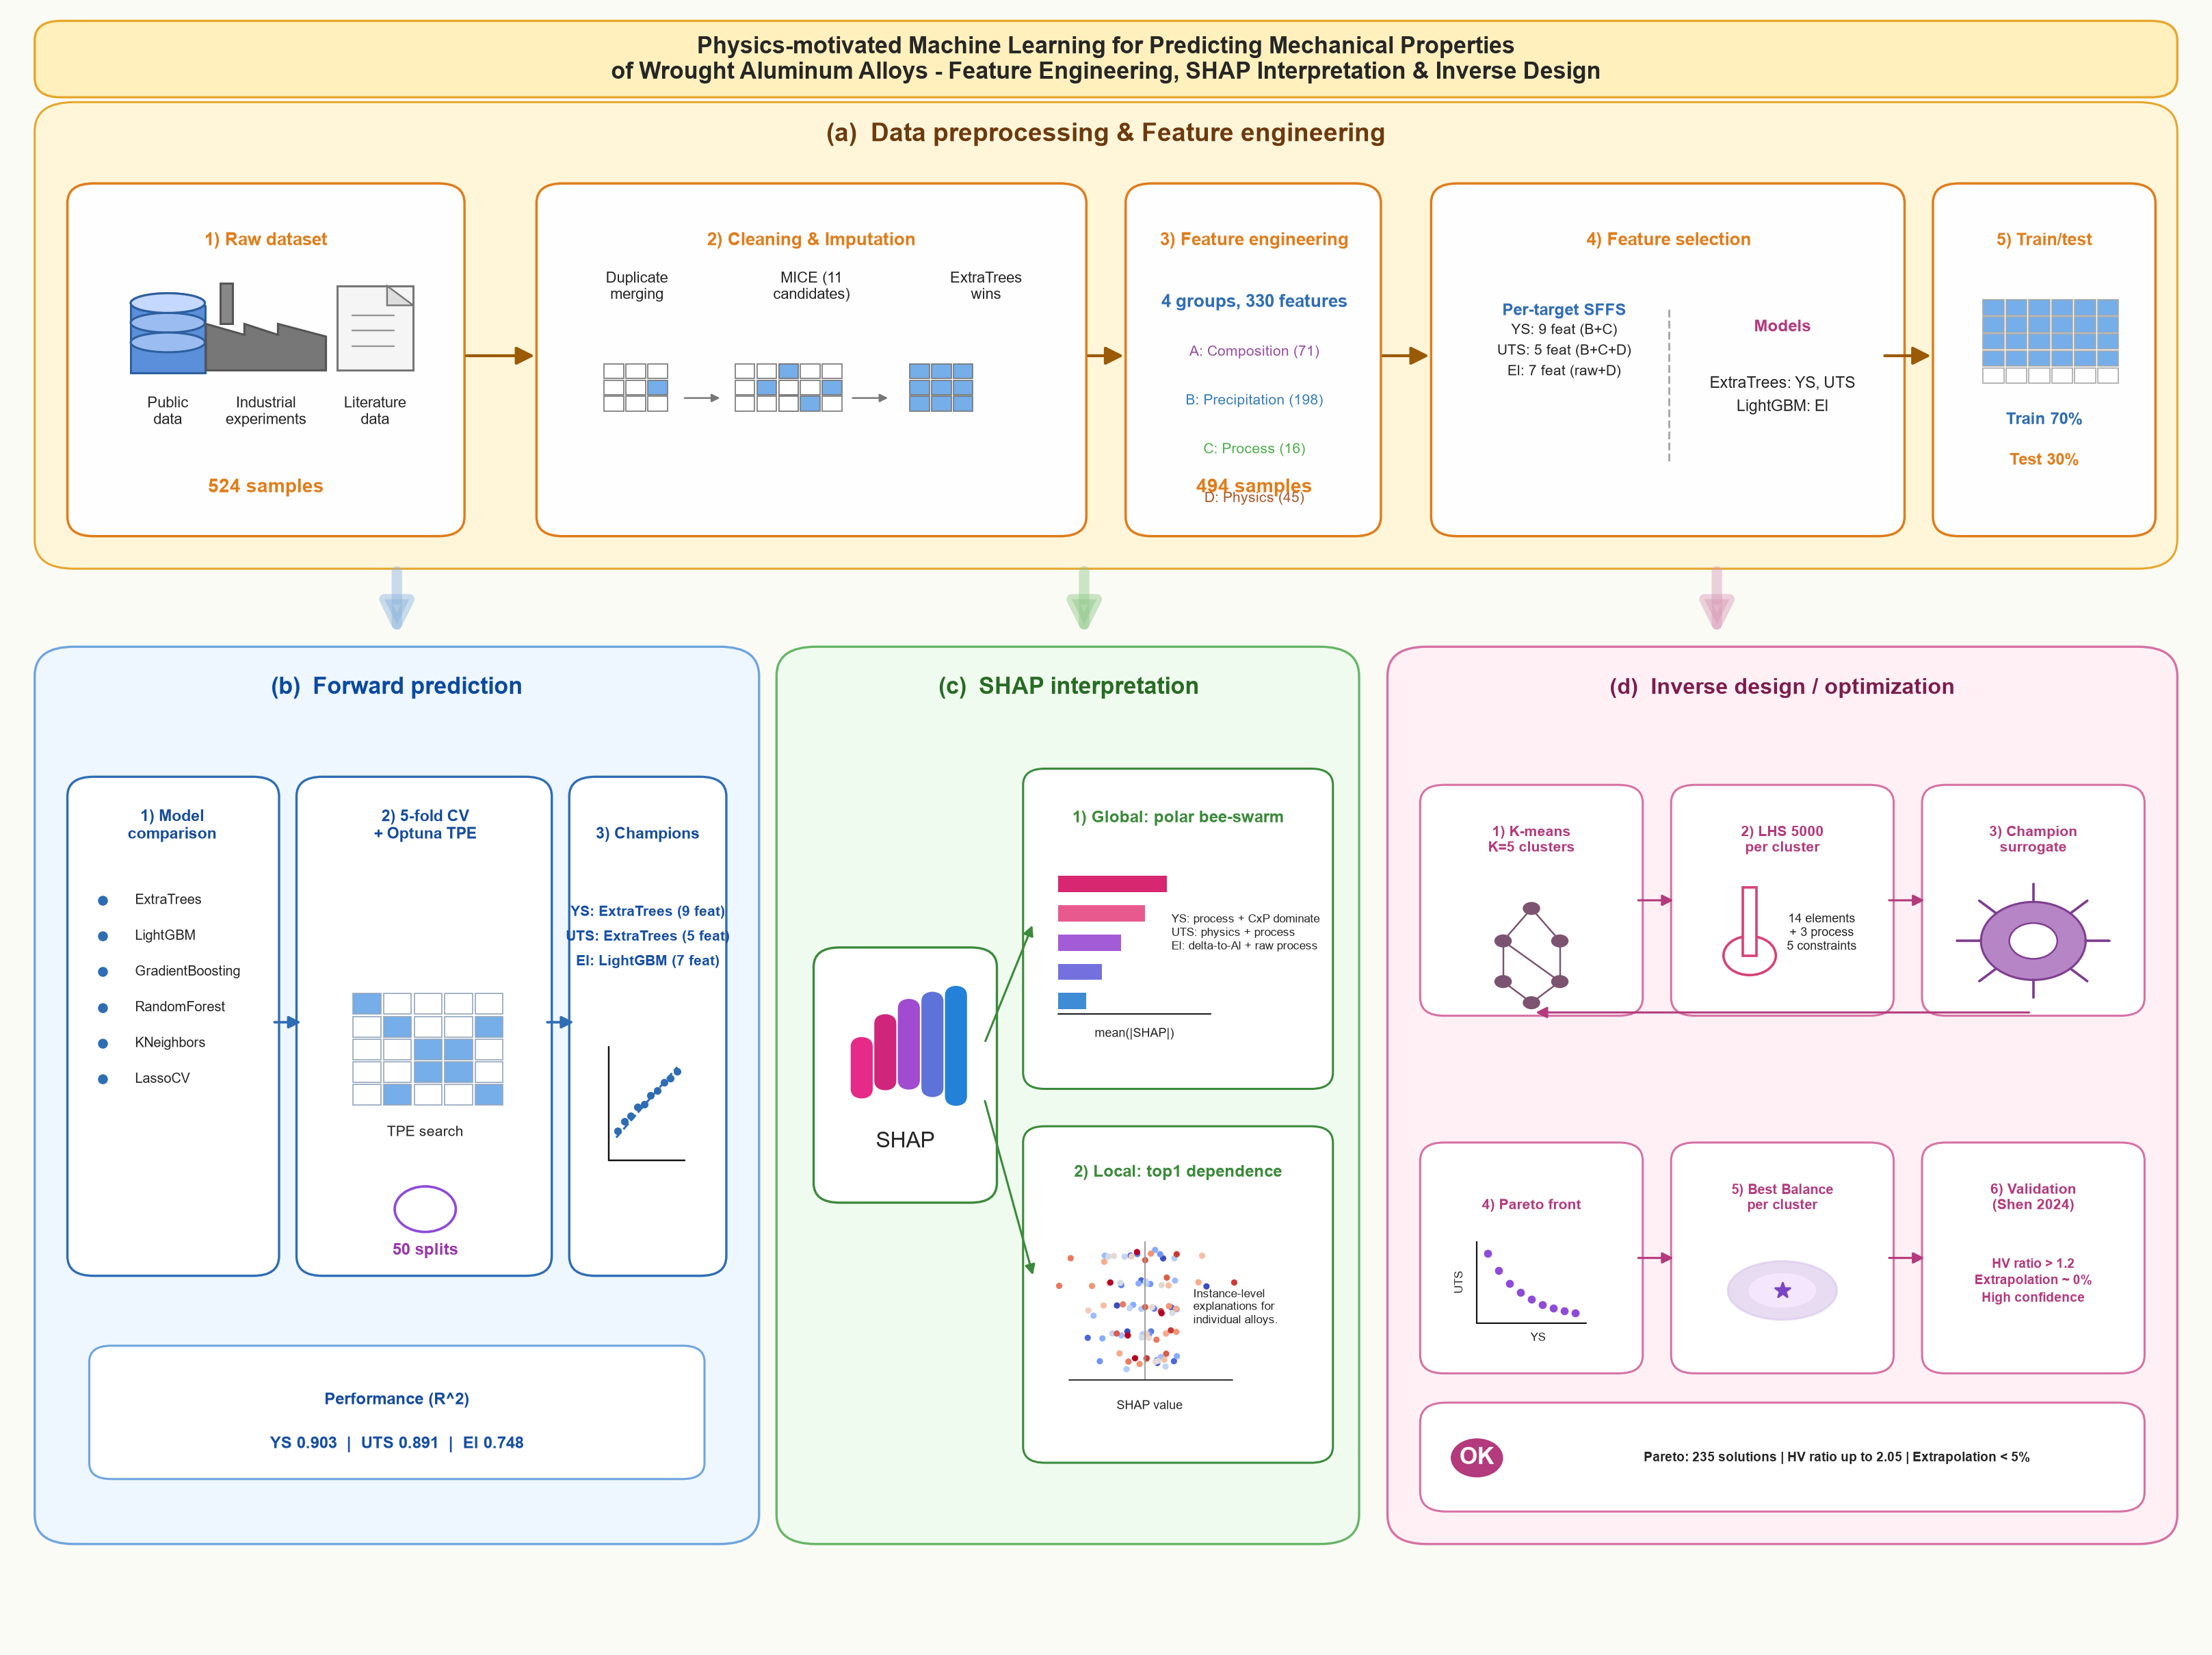

Graphical Abstract saved.


In [5]:
# ── Helper drawing functions ──
def rounded(ax, x, y, w, h, fc, ec, lw=1.2, r=0.012):
    p = FancyBboxPatch((x,y), w, h, boxstyle=f"round,pad=0.006,rounding_size={r}",
                       facecolor=fc, edgecolor=ec, linewidth=lw)
    ax.add_patch(p); return p

def arrow(ax, x1, y1, x2, y2, color, lw=1.5, ms=16, alpha=1.0):
    ax.add_patch(FancyArrowPatch((x1,y1), (x2,y2), arrowstyle="-|>",
                 mutation_scale=ms, color=color, linewidth=lw, alpha=alpha))

def database(ax, x, y, s=1.0, color="#5b8fd9"):
    w, h = 0.034*s, 0.055*s
    ax.add_patch(Rectangle((x-w/2,y-h/2), w, h*0.75, fc=color, ec="#2d5f9d", lw=1))
    for yy in [y+h*0.28, y+h*0.06, y-h*0.16]:
        ax.add_patch(Ellipse((x,yy), w, h*0.22, fc="#9bbcf0", ec="#2d5f9d", lw=1))
    ax.add_patch(Ellipse((x,y+h*0.28), w, h*0.22, fc="#c5d8ff", ec="#2d5f9d", lw=1))

def document(ax, x, y, s=1.0):
    w, h = 0.035*s, 0.052*s
    ax.add_patch(Rectangle((x-w/2,y-h/2), w, h, fc="#f5f5f5", ec="#777", lw=1))
    ax.add_patch(Polygon([[x+w/2-0.012*s,y+h/2],[x+w/2,y+h/2-0.012*s],
                 [x+w/2-0.012*s,y+h/2-0.012*s]], fc="#ddd", ec="#777", lw=0.8))
    for i in range(3):
        ax.plot([x-w*0.3, x+w*0.25], [y+h*0.15-i*h*0.18, y+h*0.15-i*h*0.18],
                color="#999", lw=0.8)

def factory(ax, x, y, s=1.0):
    w, h = 0.055*s, 0.052*s
    pts = [(x-w/2,y-h/2),(x-w/2,y+h*0.05),(x-w*0.18,y-h*0.08),(x-w*0.18,y+h*0.05),
           (x+w*0.10,y-h*0.08),(x+w*0.10,y+h*0.05),(x+w/2,y-h*0.10),(x+w/2,y-h/2)]
    ax.add_patch(Polygon(pts, fc="#777", ec="#555", lw=1))
    ax.add_patch(Rectangle((x-w*0.38,y+h*0.05), w*0.10, h*0.48, fc="#888", ec="#555", lw=1))

def grid(ax, x, y, rows, cols, cell, fill=None, edge="#aaa", fc="#fff"):
    for r in range(rows):
        for c in range(cols):
            col = fc
            if fill and fill(r, c): col = "#75aee8"
            ax.add_patch(Rectangle((x+c*cell, y-r*cell), cell*0.9, cell*0.9,
                                   fc=col, ec=edge, lw=0.55))

def scatter_icon(ax, x, y, w, h, color="#2369bd"):
    ax.plot([x,x],[y,y+h], c="#111", lw=0.8)
    ax.plot([x,x+w],[y,y], c="#111", lw=0.8)
    xs = np.linspace(x+w*0.12, x+w*0.90, 10)
    ys = y + h*0.2 + (xs-x)/w*h*0.65 + np.array([-.02,.01,0,.02,-.01,.01,0,.015,-.005,0])*h
    ax.scatter(xs, ys, s=7, c=color)
    ax.plot([x+w*0.1, x+w*0.9], [y+h*0.2, y+h*0.82], c=color, lw=1, ls="--")

def shap_logo(ax, x, y, s=1.0):
    cols = ["#e62a87","#cf267c","#a04bd0","#5d73d7","#2381d8"]
    for i, c in enumerate(cols):
        ax.add_patch(FancyBboxPatch((x+i*0.012*s, y+0.006*np.sin(i)),
                     0.009*s, (0.04+0.01*i)*s, boxstyle="round,pad=0.001,rounding_size=0.006",
                     fc=c, ec="none"))

# ── Main build ──
fig = plt.figure(figsize=(14.5, 10.8), dpi=220)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
fig.patch.set_facecolor("#fbfbf6")

orange = "#df7d1c"; blue = "#2f6db3"; green = "#3b8a3b"; magenta = "#b33a7c"

# Title
rounded(ax, .015, .955, .97, .035, "#fff0bd", "#e6a72d", 1.1, .012)
ax.text(.5, .972,
    "Physics-motivated Machine Learning for Predicting Mechanical Properties\n"
    "of Wrought Aluminum Alloys - Feature Engineering, SHAP Interpretation & Inverse Design",
    ha="center", va="center", fontsize=11, weight="bold")

# ═══════════════ (a) Data preprocessing & Feature engineering ═══════════════
rounded(ax, .015, .665, .97, .275, "#fff6da", "#e6a72d", 1, .018)
ax.text(.5, .922, "(a)  Data preprocessing & Feature engineering", ha="center",
        fontsize=12, weight="bold", color="#6c3a0e")

subs = [(.03,.685,.17,.205),(.245,.685,.24,.205),(.515,.685,.105,.205),
        (.655,.685,.205,.205),(.885,.685,.09,.205)]
for b in subs: rounded(ax, *b, "#fffefe", orange, 1.15, .012)

# 1) Raw dataset
ax.text(.115, .858, "1) Raw dataset", ha="center", fontsize=8.5, weight="bold", color=orange)
database(ax, .07, .807); factory(ax, .115, .807); document(ax, .165, .807)
ax.text(.07, .748, "Public\ndata", ha="center", fontsize=7.3)
ax.text(.115, .748, "Industrial\nexperiments", ha="center", fontsize=7.3)
ax.text(.165, .748, "Literature\ndata", ha="center", fontsize=7.3)
ax.text(.115, .706, "524 samples", ha="center", fontsize=9, weight="bold", color=orange)

# 2) Cleaning
ax.text(.365, .858, "2) Cleaning & Imputation", ha="center", fontsize=8.5, weight="bold", color=orange)
ax.text(.285, .825, "Duplicate\nmerging", ha="center", fontsize=7.1)
grid(ax, .27, .776, 3, 3, .010, lambda r,c: r==1 and c==2, edge="#777")
arrow(ax, .305, .764, .325, .764, "#777", .8, 8)
grid(ax, .33, .776, 3, 3, .010, lambda r,c: r==1 and c>=1, edge="#777")
ax.text(.365, .825, "MICE (11\ncandidates)", ha="center", fontsize=7.1)
grid(ax, .35, .776, 3, 3, .010, lambda r,c: (r+c)%3==0, edge="#777")
arrow(ax, .382, .764, .402, .764, "#777", .8, 8)
grid(ax, .41, .776, 3, 3, .010, lambda r,c: True, edge="#777")
ax.text(.445, .825, "ExtraTrees\nwins", ha="center", fontsize=7.1)

# 3) Feature engineering
ax.text(.568, .858, "3) Feature engineering", ha="center", fontsize=8.5, weight="bold", color=orange)
ax.text(.568, .820, "4 groups, 330 features", ha="center", fontsize=8.5, weight="bold", color=blue)
for gi, (gn, gc, gy) in enumerate([
    ("A: Composition (71)", "#984ea3", .790),
    ("B: Precipitation (198)", "#377eb8", .760),
    ("C: Process (16)", "#4daf4a", .730),
    ("D: Physics (45)", "#a65628", .700)]):
    ax.text(.568, gy, gn, ha="center", fontsize=6.8, color=gc)
ax.text(.568, .706, "494 samples", ha="center", fontsize=9, weight="bold", color=orange)

# 4) Feature selection
ax.text(.758, .858, "4) Feature selection", ha="center", fontsize=8.5, weight="bold", color=orange)
ax.text(.71, .815, "Per-target SFFS", ha="center", fontsize=8, weight="bold", color=blue)
ax.text(.71, .778, "YS: 9 feat (B+C)\nUTS: 5 feat (B+C+D)\nEl: 7 feat (raw+D)",
        ha="center", fontsize=7, linespacing=1.5)
ax.plot([.758, .758], [.725, .82], c="#aaa", lw=1, ls="--")
ax.text(.81, .805, "Models", ha="center", fontsize=8, weight="bold", color=magenta)
ax.text(.81, .756, "ExtraTrees: YS, UTS\nLightGBM: El",
        ha="center", fontsize=7.6, linespacing=1.6)

# 5) Split
ax.text(.93, .858, "5) Train/test", ha="center", fontsize=8.2, weight="bold", color=orange)
grid(ax, .902, .815, 5, 6, .0105, lambda r,c: (r*6+c)<24, edge="#aaa")
ax.text(.93, .748, "Train 70%", ha="center", fontsize=8, weight="bold", color=blue)
ax.text(.93, .723, "Test 30%", ha="center", fontsize=8, weight="bold", color=orange)

for x1,x2 in [(.205,.24),(.49,.51),(.625,.65),(.855,.88)]:
    arrow(ax, x1, .79, x2, .79, "#9b5a06", 1.4, 18)

# ═══════════════ Lower 3 panels ═══════════════
rounded(ax, .015, .065, .32, .54, "#eef6ff", "#6fa5de", 1.1, .018)
rounded(ax, .355, .065, .255, .54, "#f0fbef", "#67b567", 1.1, .018)
rounded(ax, .635, .065, .35, .54, "#fff0f6", "#d672a3", 1.1, .018)
arrow(ax, .175, .66, .175, .615, "#8eb5dd", 5, 30, .45)
arrow(ax, .49, .66, .49, .615, "#8fc889", 5, 30, .45)
arrow(ax, .78, .66, .78, .615, "#d99ab8", 5, 30, .45)

# (b) Forward prediction
ax.text(.175, .582, "(b)  Forward prediction", ha="center", fontsize=11, weight="bold", color="#0b4a9e")
for bx in [(.03,.23,.085,.295),(.135,.23,.105,.295),(.26,.23,.06,.295)]:
    rounded(ax, *bx, "#fff", blue, 1.1, .012)

ax.text(.072, .493, "1) Model\ncomparison", ha="center", fontsize=7.7, weight="bold", color="#164c9d")
for i, m in enumerate(["ExtraTrees","LightGBM","GradientBoosting","RandomForest","KNeighbors","LassoCV"]):
    ax.scatter([.04], [.455-i*.022], s=14, c=blue)
    ax.text(.055, .455-i*.022, m, ha="left", va="center", fontsize=6.5)

ax.text(.188, .493, "2) 5-fold CV\n+ Optuna TPE", ha="center", fontsize=7.5, weight="bold", color="#164c9d")
grid(ax, .155, .385, 5, 5, .014, lambda r,c: r==c or (r+c)%5==0, edge="#96a8bd")
ax.text(.188, .31, "TPE search", ha="center", fontsize=7)
ax.add_patch(Circle((.188, .265), .014, fc="#fff", ec="#8e4bd8", lw=1.2))
ax.text(.188, .237, "50 splits", ha="center", fontsize=8, weight="bold", color="#9639a8")

ax.text(.29, .493, "3) Champions", ha="center", fontsize=7.7, weight="bold", color="#164c9d")
ax.text(.29, .415, "YS: ExtraTrees (9 feat)\nUTS: ExtraTrees (5 feat)\nEl: LightGBM (7 feat)",
        ha="center", fontsize=7, weight="bold", color="#174fa3", linespacing=1.8)
scatter_icon(ax, .272, .295, .035, .07, blue)
arrow(ax, .117, .38, .133, .38, blue, 1.2, 12)
arrow(ax, .242, .38, .258, .38, blue, 1.2, 12)

rounded(ax, .04, .105, .27, .07, "#fff", "#6fa5de", 1, .01)
ax.text(.175, .145, "Performance (R^2)", ha="center", fontsize=8, weight="bold", color="#164c9d")
ax.text(.175, .118, "YS 0.903  |  UTS 0.891  |  El 0.748", ha="center",
        fontsize=8, weight="bold", color="#174fa3")

# (c) SHAP interpretation
ax.text(.483, .582, "(c)  SHAP interpretation", ha="center", fontsize=11, weight="bold", color="#286b24")
rounded(ax, .372, .275, .072, .145, "#fff", green, 1.1, .012)
shap_logo(ax, .384, .334, 0.90)
ax.text(.408, .303, "SHAP", ha="center", fontsize=10.5)

rounded(ax, .468, .345, .130, .185, "#fff", green, 1, .01)
ax.text(.533, .503, "1) Global: polar bee-swarm", ha="center", fontsize=7.8, weight="bold", color=green)
for i, l in enumerate([.050, .040, .029, .020, .013]):
    ax.add_patch(Rectangle((.478, .460-i*.018), l, .010,
                 fc=["#d62770","#e85a8d","#a45bd6","#7471de","#3e8bd6"][i], ec="none"))
ax.plot([.478, .548], [.385, .385], c="#222", lw=.7)
ax.text(.513, .371, "mean(|SHAP|)", ha="center", fontsize=5.8)
ax.text(.530, .435, "YS: process + CxP dominate\nUTS: physics + process\nEl: delta-to-Al + raw process",
        ha="left", va="center", fontsize=5.5, linespacing=1.25)

rounded(ax, .468, .115, .130, .195, "#fff", green, 1, .01)
ax.text(.533, .285, "2) Local: top1 dependence", ha="center", fontsize=7.8, weight="bold", color=green)
x0, y0 = .478, .160
ax.plot([x0+.040, x0+.040], [y0, y0+.085], c="#999", lw=.6)
rng2 = np.random.default_rng(1)
for row in range(5):
    xs = x0+.040+rng2.normal(0,.016,18)
    ys = y0+.012+row*.016+rng2.normal(0,.002,18)
    ax.scatter(xs, ys, s=4, c=np.linspace(0,1,18), cmap="coolwarm", vmin=0, vmax=1)
ax.plot([x0+.005, x0+.080], [y0, y0], c="#222", lw=.6)
ax.text(x0+.042, y0-.018, "SHAP value", ha="center", fontsize=5.8)
ax.text(.540, .205, "Instance-level\nexplanations for\nindividual alloys.",
        ha="left", va="center", fontsize=5.5, linespacing=1.25)
arrow(ax, .444, .366, .467, .442, green, 1.0, 10)
arrow(ax, .444, .334, .467, .222, green, 1.0, 10)

# (d) Inverse design
ax.text(.81, .582, "(d)  Inverse design / optimization", ha="center", fontsize=10.5, weight="bold", color="#7c1d4d")

steps = [(.65,.39,.09,.13),(.765,.39,.09,.13),(.88,.39,.09,.13),
         (.65,.17,.09,.13),(.765,.17,.09,.13),(.88,.17,.09,.13)]
for sb in steps: rounded(ax, *sb, "#fff", "#d672a3", 1, .011)

ax.text(.695, .485, "1) K-means\nK=5 clusters", ha="center", fontsize=6.8, weight="bold", color=magenta)
nodes = [(.682,.43),(.695,.45),(.708,.43),(.708,.405),(.682,.405),(.695,.392)]
for i,j in [(0,1),(1,2),(2,3),(3,5),(5,4),(4,0),(0,3)]:
    ax.plot([nodes[i][0],nodes[j][0]],[nodes[i][1],nodes[j][1]],c="#7c5371",lw=.8)
for n in nodes: ax.add_patch(Circle(n,.004,fc="#7c5371",ec="none"))

ax.text(.81, .485, "2) LHS 5000\nper cluster", ha="center", fontsize=6.8, weight="bold", color=magenta)
ax.add_patch(Circle((.795,.421),.012,fc="#fff",ec="#d74374",lw=1.2))
ax.add_patch(Rectangle((.792,.421),.006,.042,fc="#fff",ec="#d74374",lw=1.2))
ax.text(.828, .435, "14 elements\n+ 3 process\n5 constraints",
        ha="center", va="center", fontsize=6)

ax.text(.925, .485, "3) Champion\nsurrogate", ha="center", fontsize=6.8, weight="bold", color=magenta)
ax.add_patch(Circle((.925,.43),.024,fc="#b685c6",ec="#7e3d90",lw=1))
ax.add_patch(Circle((.925,.43),.011,fc="#fff",ec="#7e3d90",lw=.8))
for ang in np.linspace(0,2*np.pi,8,endpoint=False):
    ax.plot([.925+.024*np.cos(ang),.925+.035*np.cos(ang)],
            [.43+.024*np.sin(ang),.43+.035*np.sin(ang)],c="#7e3d90",lw=1.2)

ax.text(.695, .265, "4) Pareto front", ha="center", fontsize=6.8, weight="bold", color=magenta)
ax.plot([.67,.67],[.195,.245],c="#111",lw=.7)
ax.plot([.67,.72],[.195,.195],c="#111",lw=.7)
xs_p = np.linspace(.675,.715,9)
ys_p = .238-.04*(1-np.exp(-np.linspace(0,2.5,9)))
ax.scatter(xs_p, ys_p, s=8, c="#8e4bd8")
ax.text(.662,.22,"UTS",ha="center",va="center",rotation=90,fontsize=5.5)
ax.text(.698,.184,"YS",ha="center",fontsize=5.5)

ax.text(.81, .265, "5) Best Balance\nper cluster", ha="center", fontsize=6.5, weight="bold", color=magenta)
th = np.linspace(0,2*np.pi,80)
ax.fill(.81+.025*np.cos(th), .215+.018*np.sin(th), c="#d9c6eb", alpha=.6)
ax.fill(.81+.015*np.cos(th), .215+.010*np.sin(th), c="#f6e8ff", alpha=.9)
ax.scatter([.81],[.215],marker="*",s=55,c="#7a45c5")

ax.text(.925, .265, "6) Validation\n(Shen 2024)", ha="center", fontsize=6.8, weight="bold", color=magenta)
ax.text(.925, .221, "HV ratio > 1.2\nExtrapolation ~ 0%\nHigh confidence",
        ha="center", va="center", fontsize=6.2, weight="bold", color=magenta, linespacing=1.45)

for (xa,xb,ya) in [(.742,.762,.455),(.857,.877,.455),(.925,.695,.386),
                    (.742,.762,.235),(.857,.877,.235)]:
    arrow(ax, xa, ya, xb, ya, magenta, 1, 11)

rounded(ax, .65, .085, .32, .055, "#fff", "#d672a3", 1, .012)
ax.add_patch(Circle((.67,.112),.012,fc=magenta,ec="none"))
ax.text(.67,.112,"OK",ha="center",va="center",fontsize=11,color="#fff",weight="bold")
ax.text(.835,.112,"Pareto: 235 solutions | HV ratio up to 2.05 | Extrapolation < 5%",
        ha="center",va="center",fontsize=6.2,weight="bold")

save_fig(fig, 'Graphical_Abstract')
plt.show()
print('Graphical Abstract saved.')


## Figure 1: EDA PairGrid

20 variables: 14 elements + 3 process parameters + 3 targets (YS, UTS, El).
Data: seed=42 MICE-imputed `metal_cleaned.csv` (494 samples).

Style reference: `archive/9.visualization.ipynb` EDA.

- **Diagonal**: histogram + KDE + skewness/kurtosis annotation
- **Upper triangle**: scatter + linear fit + 95% confidence interval
- **Lower triangle**: Pearson correlation coefficient (coolwarm color block)


EDA data shape: (422, 20)
Columns (20): ['Si', 'Fe', 'Cu', 'Mn', 'Mg', 'Cr', 'Zn', 'V', 'Ti', 'Zr', 'Li', 'Ni', 'Be', 'Sc', 'Tsol', 'Tage', 'tage', 'YS', 'UTS', 'El']
  -> Fig1_EDA_PairGrid.pdf


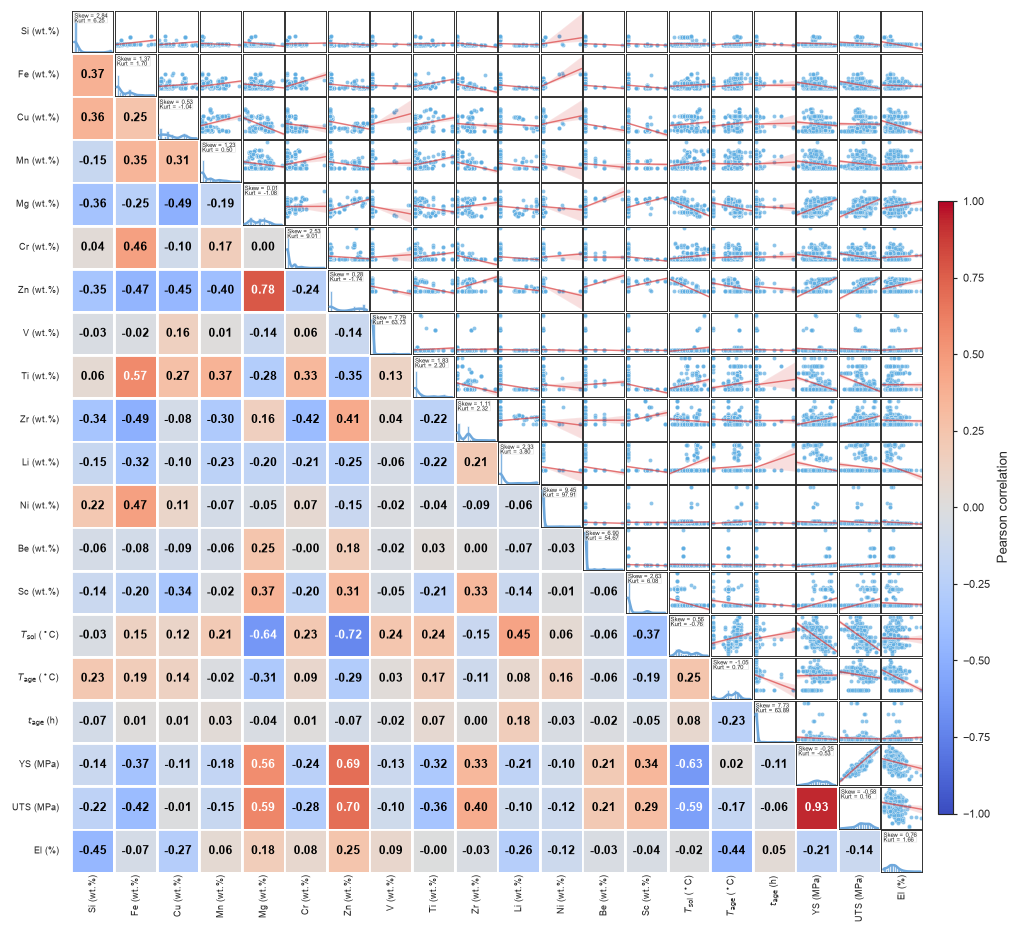

Figure 1 saved.


In [6]:
# ── Load data ──
df_raw = pd.read_csv(os.path.join(DATA_DIR, 'metal_cleaned.csv'))

# 20 variables: 14 elements + 3 process + 3 targets
selected_cols = ELEMENTS + PROCESS_COLS + TARGET_COLS

missing = [c for c in selected_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df_eda = df_raw[selected_cols].copy()
df_eda = df_eda.apply(pd.to_numeric, errors='coerce')
df_eda = df_eda.dropna(axis=0, how='any').reset_index(drop=True)

print(f"EDA data shape: {df_eda.shape}")
print(f"Columns ({len(selected_cols)}): {selected_cols}")

# ── Label map ──
label_map = {
    'Si': 'Si (wt.%)', 'Fe': 'Fe (wt.%)', 'Cu': 'Cu (wt.%)',
    'Mn': 'Mn (wt.%)', 'Mg': 'Mg (wt.%)', 'Cr': 'Cr (wt.%)',
    'Zn': 'Zn (wt.%)', 'V': 'V (wt.%)', 'Ti': 'Ti (wt.%)',
    'Zr': 'Zr (wt.%)', 'Li': 'Li (wt.%)', 'Ni': 'Ni (wt.%)',
    'Be': 'Be (wt.%)', 'Sc': 'Sc (wt.%)',
    'Tsol': r'$T_{\mathrm{sol}}$ ($^\circ$C)',
    'Tage': r'$T_{\mathrm{age}}$ ($^\circ$C)',
    'tage': r'$t_{\mathrm{age}}$ (h)',
    'YS': 'YS (MPa)', 'UTS': 'UTS (MPa)', 'El': 'El (%)',
}

# ── Compute stats ──
dist_stats = pd.DataFrame({
    'Skewness': df_eda.skew(numeric_only=True),
    'Kurtosis': df_eda.kurt(numeric_only=True)
})
corr_matrix = df_eda.corr(method='pearson', numeric_only=True)

# ── PairGrid functions ──
def plot_diag(x, **kwargs):
    ax = plt.gca(); col = x.name
    sns.histplot(x=x, bins=16, kde=True, color='#6FA8DC', edgecolor='white',
                 linewidth=0.35, alpha=0.85, ax=ax)
    text = (f"Skew = {dist_stats.loc[col, 'Skewness']:.2f}\n"
            f"Kurt = {dist_stats.loc[col, 'Kurtosis']:.2f}")
    ax.text(0.05, 0.95, text, transform=ax.transAxes, ha='left', va='top',
            fontsize=3.6, linespacing=0.85,
            bbox=dict(boxstyle='round,pad=0.04', fc='white', ec='0.80',
                      lw=0.35, alpha=0.58))
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(axis='both', which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    for spine in ax.spines.values(): spine.set_linewidth(0.55)

def plot_upper(x, y, **kwargs):
    ax = plt.gca()
    sns.regplot(x=x, y=y, ci=95, n_boot=500, truncate=False,
                scatter_kws={'s': 6, 'alpha': 0.7, 'color': '#5DADE2',
                             'edgecolors': 'white', 'linewidths': 0.2},
                line_kws={'linewidth': 0.85, 'color': '#D62728', 'alpha': 0.6},
                ax=ax)
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(axis='both', which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    for spine in ax.spines.values(): spine.set_linewidth(0.55)

def plot_lower(x, y, **kwargs):
    ax = plt.gca()
    r = corr_matrix.loc[y.name, x.name]
    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(vmin=-1, vmax=1)
    ax.set_facecolor(cmap(norm(r)))
    text_color = 'white' if abs(r) > 0.55 else 'black'
    ax.text(0.5, 0.5, f'{r:.2f}', ha='center', va='center', fontsize=7.4,
            fontweight='bold', color=text_color, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    ax.tick_params(axis='both', which='both', bottom=False, top=False,
                   left=False, right=False, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.45); spine.set_color('white')

# ── Draw ──
sns.set_style('white')
g = sns.PairGrid(df_eda, corner=False, height=1.35, aspect=1.0, despine=False)
g.map_upper(plot_upper)
g.map_diag(plot_diag)
g.map_lower(plot_lower)

n_vars = len(df_eda.columns)
g.fig.set_size_inches(8.8, 8.8)
g.fig.subplots_adjust(left=0.115, bottom=0.145, top=0.96, right=0.92,
                       wspace=0.04, hspace=0.04)

# Colorbar
cbar_ax = g.fig.add_axes([0.935, 0.20, 0.014, 0.58])
cb = ColorbarBase(cbar_ax, cmap=plt.get_cmap('coolwarm'),
                  norm=Normalize(vmin=-1, vmax=1), orientation='vertical')
cb.set_label('Pearson correlation', fontsize=7.5)
cb.ax.tick_params(labelsize=6.5, width=0.7, length=2.5)

# Clean up ticks & add labels
for i in range(n_vars):
    for j in range(n_vars):
        ax = g.axes[i, j]
        ax.set_xticks([]); ax.set_yticks([])
        ax.tick_params(axis='both', which='both', bottom=False, top=False,
                       left=False, right=False, labelbottom=False, labelleft=False)
        for spine in ax.spines.values(): spine.set_linewidth(0.55)

for ax in g.axes.flat:
    ax.set_xlabel(''); ax.set_ylabel('')

for j, col in enumerate(df_eda.columns):
    g.axes[-1, j].set_xlabel(label_map.get(col, col), fontsize=5.6,
                              rotation=90, ha='center', va='top', labelpad=2)
for i, col in enumerate(df_eda.columns):
    g.axes[i, 0].set_ylabel(label_map.get(col, col), fontsize=5.6,
                             rotation=0, ha='right', va='center', labelpad=8)

save_fig(g.fig, 'Fig1_EDA_PairGrid')
plt.show()
print('Figure 1 saved.')


## Figure 2: Model Comparison

**Upper row (a-c)**: Per-target dual Y-axis grouped bar chart.
- Left Y-axis: RMSE (filled bar + error bar) and MAE (hatched bar + error bar)
- Right Y-axis: R^2 (bar + error bar)
- 6 models on X-axis, sorted by RMSE ascending
- Error bars = CV standard deviation
- Best model marked with red star

**Lower row (d-f)**: Phase B 50-split predicted vs measured scatter.
- Data from `plot_phase_b.npz` (concatenated across all 50 splits)
- R^2 and RMSE annotated


  -> Fig2_Model_Comparison.pdf


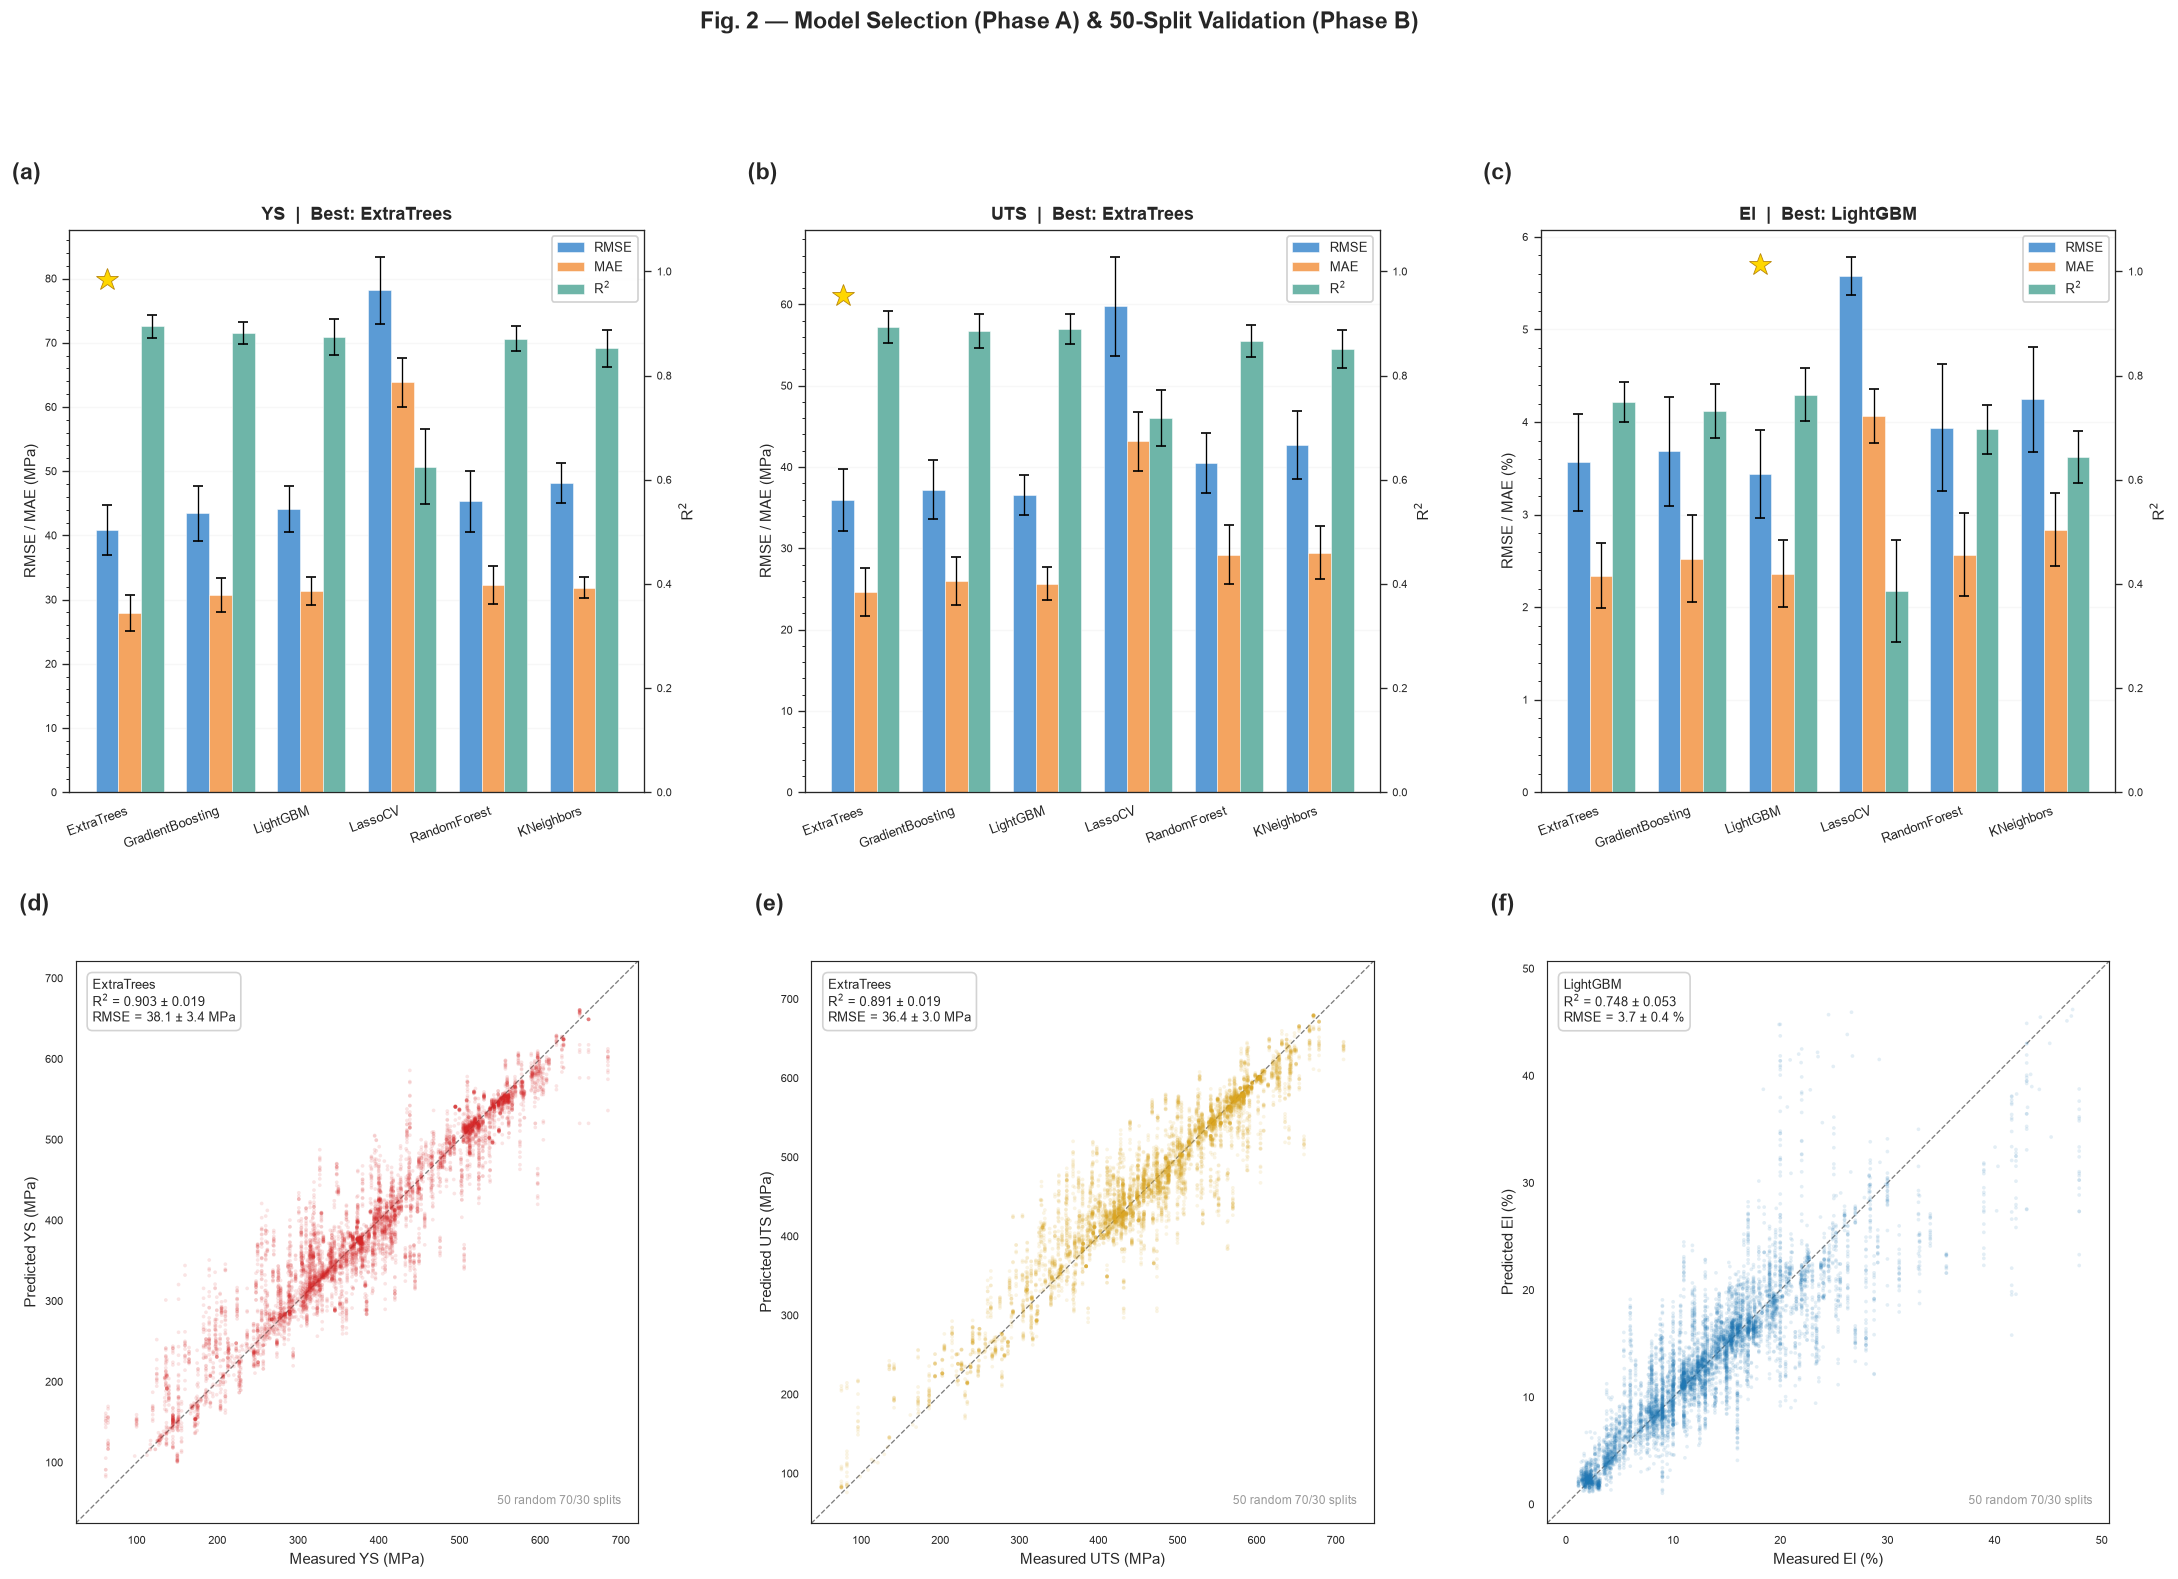

Figure 2 saved.


In [11]:
# ── Load data ──
with open(os.path.join(DATA_DIR, 'model_selection_results.json')) as f:
    msr = json.load(f)
with open(os.path.join(DATA_DIR, 'repeated_split_results.json')) as f:
    rsr = json.load(f)
_pb = np.load(os.path.join(DATA_DIR, 'plot_phase_b.npz'))

MODEL_ORDER = ['ExtraTrees', 'GradientBoosting', 'LightGBM',
               'LassoCV', 'RandomForest', 'KNeighbors']

C_RMSE = '#5B9BD5'
C_MAE  = '#F4A460'
C_R2   = '#6EB5A8'
C_SCAT = {'YS': '#d62728', 'UTS': '#DAA520', 'El': '#1f77b4'}

fig = plt.figure(figsize=(22, 14))

for ti, tn in enumerate(TARGET_COLS):
    ax = fig.add_subplot(2, 3, ti + 1)
    scores = msr[tn]['all_cv_scores']
    best_model = msr[tn]['best_model']
    u = TARGET_UNITS[tn]

    names = [m for m in MODEL_ORDER if m in scores]
    rmses = np.array([scores[m]['cv_rmse'] for m in names])
    rmses_std = np.array([scores[m]['cv_rmse_std'] for m in names])
    r2s = np.array([scores[m]['cv_r2'] for m in names])
    r2s_std = np.array([scores[m]['cv_r2_std'] for m in names])
    maes = np.array([scores[m]['cv_mae'] for m in names])
    maes_std = np.array([scores[m]['cv_mae_std'] for m in names])

    x = np.arange(len(names)); w = 0.25

    ax.bar(x - w, rmses, w, color=C_RMSE, edgecolor='white', linewidth=0.3,
           yerr=rmses_std, capsize=3, error_kw={'linewidth': 0.8}, label='RMSE')
    ax.bar(x, maes, w, color=C_MAE, edgecolor='white', linewidth=0.3,
           yerr=maes_std, capsize=3, error_kw={'linewidth': 0.8}, label='MAE')
    ax2 = ax.twinx()
    ax2.bar(x + w, r2s, w, color=C_R2, edgecolor='white', linewidth=0.3,
            yerr=r2s_std, capsize=3, error_kw={'linewidth': 0.8}, label='R$^2$')

    if best_model in names:
        bi = names.index(best_model)
        ax.plot(bi - w, max(rmses)*1.02, marker='*', markersize=14, color='#FFD700',
                markeredgecolor='#B8860B', markeredgewidth=0.5, clip_on=False)

    ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=7.5)
    ax.set_ylabel(f'RMSE / MAE ({u})', fontsize=9)
    ax2.set_ylabel('R$^2$', fontsize=9)
    ax.grid(axis='y', alpha=0.15, zorder=0); ax2.set_ylim(0, 1.08); ax.set_ylim(bottom=0)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right',
              framealpha=0.9, edgecolor='#CCCCCC')
    ax.set_title(f'{tn}  |  Best: {best_model}', fontsize=11, fontweight='bold')
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    add_label(ax, f'({chr(97+ti)})')

for ti, tn in enumerate(TARGET_COLS):
    ax = fig.add_subplot(2, 3, ti + 4)
    yt = _pb[f'{tn}_true']
    yp = _pb[f'{tn}_pred']
    cc = C_SCAT[tn]

    r2_m = rsr[tn]['r2_mean']; r2_s = rsr[tn]['r2_std']
    rmse_m = rsr[tn]['rmse_mean']; rmse_s = rsr[tn]['rmse_std']
    best_model = msr[tn]['best_model']; u = TARGET_UNITS[tn]

    ax.scatter(yt, yp, c=cc, s=5, alpha=0.12, marker='o',
               edgecolors='none', rasterized=True, zorder=2)

    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    pad = (lims[1]-lims[0])*0.06; lims = [lims[0]-pad, lims[1]+pad]
    ax.plot(lims, lims, 'k--', lw=0.8, zorder=1, alpha=0.5)

    s1 = f'{best_model}'
    s2 = f'R$^2$ = {r2_m:.3f} ' + chr(177) + f' {r2_s:.3f}'
    s3 = f'RMSE = {rmse_m:.1f} ' + chr(177) + f' {rmse_s:.1f} {u}'
    stats = s1 + chr(10) + s2 + chr(10) + s3
    ax.text(0.03, 0.97, stats, transform=ax.transAxes, fontsize=8,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85,
                      edgecolor='#CCCCCC'))

    ax.set_xlabel(f'Measured {tn} ({u})', fontsize=9)
    ax.set_ylabel(f'Predicted {tn} ({u})', fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.text(0.97, 0.03, '50 random 70/30 splits', transform=ax.transAxes,
            fontsize=7, va='bottom', ha='right', color='#999999')
    add_label(ax, f'({chr(100+ti)})')

fig.suptitle('Fig. 2 ' + chr(8212) + ' Model Selection (Phase A) & 50-Split Validation (Phase B)',
             fontsize=14, y=1.01, fontweight='bold')
plt.subplots_adjust(hspace=0.30, wspace=0.28)
save_fig(fig, 'Fig2_Model_Comparison')
plt.show()
print('Figure 2 saved.')

## Figure 3: SHAP Analysis

**Upper row (a-c)**: Polar bee-swarm (rose) plots for YS, UTS, El.
**Lower row (d-f)**: Top-1 SHAP dependence scatter per target.

Data: pre-computed SHAP values from N05 (`shap_plot_data.npz`, `shap_plot_meta.json`).


  -> Fig3_SHAP.pdf


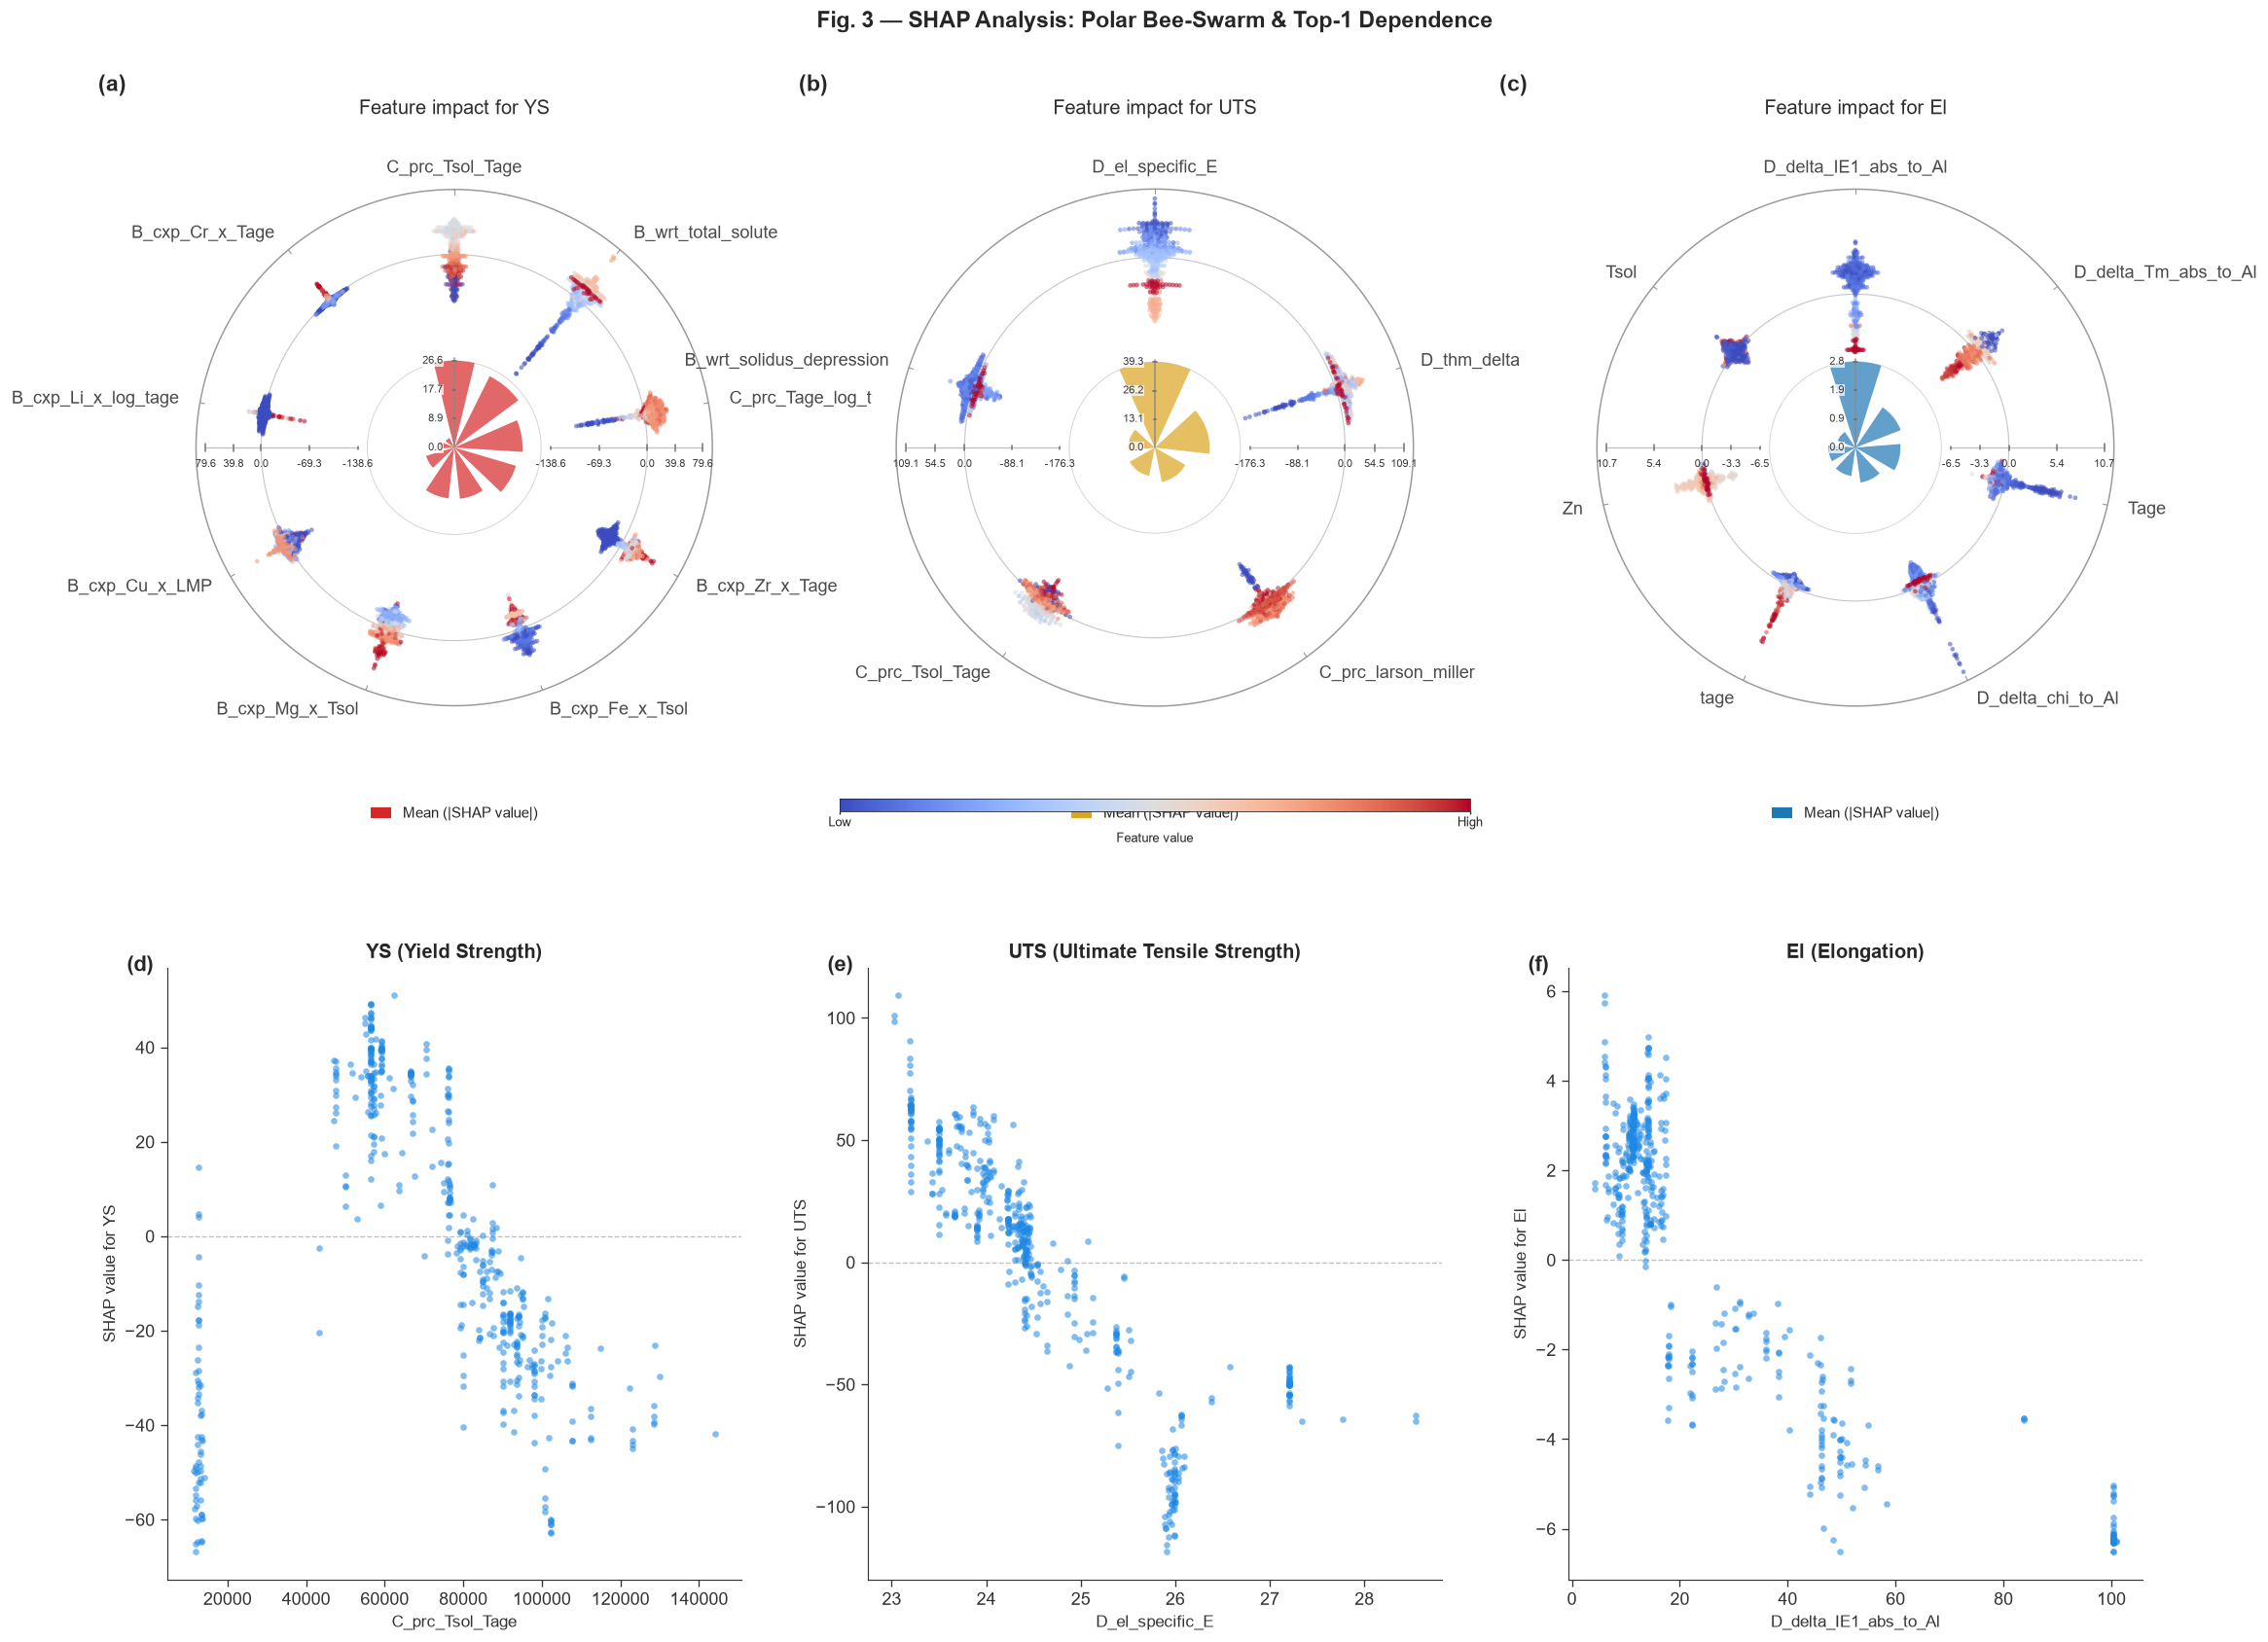

Figure 3 saved.


In [16]:
# ── Load pre-computed SHAP data (N05) ──
shap_data = np.load(os.path.join(DATA_DIR, 'shap_plot_data.npz'), allow_pickle=True)
with open(os.path.join(DATA_DIR, 'shap_plot_meta.json')) as f:
    shap_meta = json.load(f)

shap_results = {}
for tn in TARGET_COLS:
    shap_results[tn] = {
        'values': shap_data[f'{tn}_shap_values'],
        'X_raw': shap_data[f'{tn}_X_raw'],
        'feat_names': shap_meta[tn]['feat_names'],
    }

TARGET_COLORS_N05 = {'YS': '#d62728', 'UTS': '#DAA520', 'El': '#1f77b4'}
TARGET_LABELS = {'YS': 'Yield Strength', 'UTS': 'Ultimate Tensile Strength', 'El': 'Elongation'}

# ═══════════════════════════════════════════════════════════
# Polar bee-swarm helpers (exact copy from N05 cell 20)
# ═══════════════════════════════════════════════════════════
from matplotlib.transforms import offset_copy
from matplotlib.patches import Patch
import shap

def simple_beeswarm_n05(y, nbins=None, width=1.0):
    y = np.asarray(y)
    if nbins is None:
        nbins = max(len(y) // 6, 1)
    nbins = int(nbins)
    x = np.zeros(len(y))
    ylo, yhi = np.min(y), np.max(y)
    if ylo == yhi:
        return x
    dy = (yhi - ylo) / nbins
    ybins = np.linspace(ylo + dy, yhi - dy, nbins - 1)
    i = np.arange(len(y))
    ibs, ybs = [None] * nbins, [None] * nbins
    nmax = 0
    for j, ybin in enumerate(ybins):
        f = y <= ybin
        ibs[j], ybs[j] = i[f], y[f]
        nmax = max(nmax, len(ibs[j]))
        f = ~f
        i, y = i[f], y[f]
    ibs[-1], ybs[-1] = i, y
    nmax = max(nmax, len(ibs[-1]))
    dx = width / (nmax // 2 + 1)
    for ii, yy in zip(ibs, ybs):
        if ii is None or len(ii) <= 1:
            continue
        j = len(ii) % 2
        ii = ii[np.argsort(yy)]
        a = ii[j::2]
        b = ii[j + 1::2]
        x[a] = (0.5 + j / 3 + np.arange(len(a))) * dx
        x[b] = (0.5 + j / 3 + np.arange(len(b))) * -dx
    return x

def _angle_text_props(angle):
    deg = (np.degrees(angle) + 360) % 360
    if 15 <= deg <= 165:
        return 'left'
    if 195 <= deg <= 345:
        return 'right'
    return 'center'

def plot_one_polar_n05(ax, sv, X_raw, feat_names, rose_color, panel_label, target_label):
    n_feat = sv.shape[1]
    cmap = plt.get_cmap('coolwarm')
    np.random.seed(42)

    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    sv_ord = sv[:, order]
    X_ord = X_raw[:, order]
    cols_ord = [feat_names[i] for i in order]
    mean_ord = mean_abs[order]

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False)
    sector = 2 * np.pi / n_feat
    swarm_width = sector * 0.16

    all_sv = sv_ord.flatten()
    shap_min = float(np.min(all_sv))
    shap_max = float(np.max(all_sv))
    max_abs = max(float(np.max(np.abs(all_sv))), 1e-12)

    inner_bar_max = max_abs * 0.9
    white_gap = max_abs * 0.1
    shift = abs(shap_min) + inner_bar_max + white_gap

    max_mean = max(float(np.max(mean_ord)), 1e-12)
    mean_bar = (mean_ord / max_mean) * inner_bar_max

    zero_r = shift
    r_min = shap_min + shift
    r_max = shap_max + shift
    outer_r = r_max + max_abs * 0.10

    title_fs, feature_fs = 12, 10.5
    legend_fs, mean_tick_fs, shap_tick_fs = 9, 6.8, 6.8
    title_color = '#2E2E2E'
    feature_color = '#4A4A4A'
    number_color = '#3A3A3A'
    guide_color = '#C8C8C8'
    outer_color = '#9A9A9A'
    axis_line_color = '#8A8A8A'
    tick_line_color = '#6F6F6F'
    shap_axis_color = '#C2C2C2'

    # Inner bar: mean |SHAP|
    bar_bottom = 0.0
    ax.bar(angles, mean_bar, width=sector * 0.68, align='center',
           bottom=bar_bottom, color=rose_color, alpha=0.7,
           edgecolor='none', zorder=3)

    # Mean-bar axis line & ticks
    angle_top = 0.0
    ax.plot([angle_top, angle_top], [bar_bottom, bar_bottom + inner_bar_max * 1.03],
            color=axis_line_color, lw=0.9, zorder=4)
    mean_tick_vals = np.linspace(0, max_mean, 4)
    for v in mean_tick_vals:
        r = bar_bottom + (v / (max_mean + 1e-12)) * inner_bar_max
        ax.plot([angle_top - 0.024, angle_top + 0.024], [r, r],
                color=tick_line_color, lw=1.0, zorder=5)
        trans = offset_copy(ax.transData, fig=ax.figure, x=-7, y=0, units='points')
        ax.text(angle_top, r, f'{v:.1f}', transform=trans,
                ha='right', va='center', fontsize=mean_tick_fs,
                color=number_color,
                bbox=dict(boxstyle='square,pad=0.05',
                          facecolor=(1, 1, 1, 0.75), edgecolor='none'),
                zorder=6)

    # Bee-swarm scatter dots
    for fi in range(n_feat):
        sv_col = sv_ord[:, fi]
        x_col = X_ord[:, fi]
        x_off = simple_beeswarm_n05(sv_col, nbins=120, width=swarm_width)
        radius = sv_col + shift
        vmin, vmax = np.percentile(x_col, [5, 95])
        if np.isclose(vmin, vmax):
            vmin, vmax = np.min(x_col), np.max(x_col)
        norm = np.clip((x_col - vmin) / (vmax - vmin + 1e-12), 0, 1)
        colors = cmap(norm)
        ax.scatter(angles[fi] + x_off, radius, c=colors, s=8,
                   alpha=0.55, linewidths=0, rasterized=True, zorder=4)

    # Guide circles
    theta = np.linspace(0, 2 * np.pi, 720)
    ax.plot(theta, np.full_like(theta, zero_r), color=guide_color, lw=0.7, zorder=1)
    ax.plot(theta, np.full_like(theta, outer_r), color=outer_color, lw=0.9, zorder=1)
    ax.plot(theta, np.full_like(theta, inner_bar_max), color='#D7D7D7', lw=0.6, zorder=1)

    # Outer tick marks
    for ang in angles:
        ax.plot([ang, ang], [outer_r - outer_r * 0.018, outer_r],
                color=outer_color, lw=0.7, zorder=1)

    # SHAP value axes & ticks (right & left sides)
    tick_vals = np.array([shap_min, shap_min / 2, 0.0, shap_max / 2, shap_max])
    tick_vals = np.unique(np.round(tick_vals, 1))
    tick_angles = [np.pi / 2, 3 * np.pi / 2]
    for angle_c in tick_angles:
        ax.plot([angle_c, angle_c], [r_min, r_max], color=shap_axis_color, lw=0.8, zorder=1)
        for val in tick_vals:
            r = val + shift
            ax.plot([angle_c - 0.016, angle_c + 0.016], [r, r],
                    color=tick_line_color, lw=0.9, zorder=2)
            trans = offset_copy(ax.transData, fig=ax.figure, x=0, y=-7, units='points')
            ax.text(angle_c, r, f'{val:.1f}', fontsize=shap_tick_fs,
                    color=number_color, ha='center', va='top',
                    transform=trans, zorder=5)

    # Feature name labels around the circle
    label_r = outer_r + max_abs * 0.22
    for ang, name in zip(angles, cols_ord):
        ha = _angle_text_props(ang)
        ax.text(ang, label_r, name, fontsize=feature_fs, fontweight='normal',
                color=feature_color, ha=ha, va='center', rotation=0,
                clip_on=False, zorder=6)

    # Titles
    ax.text(-0.12, 1.15, panel_label, transform=ax.transAxes,
            ha='left', va='top', fontsize=14, fontweight='bold', clip_on=False)
    ax.text(0.5, 1.09, f'Feature impact for {target_label}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=title_fs, fontweight='normal', color=title_color)

    # Legend
    patch = Patch(facecolor=rose_color, edgecolor='none', label='Mean (|SHAP value|)')
    ax.legend(handles=[patch], loc='lower center',
              bbox_to_anchor=(0.5, -0.16), frameon=False, fontsize=legend_fs,
              handlelength=1.4, borderaxespad=0.0)

    ax.set_ylim(0, label_r + max_abs * 0.08)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines['polar'].set_visible(False)

# ═══════════════════════════════════════════════════════════
# Single 2x3 figure: polar (top) + dependence (bottom)
# ═══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))

# Row 1 (a-c): Polar bee-swarm
for ti, tn in enumerate(TARGET_COLS):
    ax = fig.add_subplot(2, 3, ti + 1, projection='polar')
    sr = shap_results[tn]
    plot_one_polar_n05(ax, sr['values'], sr['X_raw'], sr['feat_names'],
                       rose_color=TARGET_COLORS_N05[tn],
                       panel_label=f'({chr(97+ti)})',
                       target_label=tn)

# Shared colorbar at bottom of row 1
cbar_ax = fig.add_axes([0.35, 0.52, 0.30, 0.008])
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(labelsize=8, length=2, pad=1)
cbar.outline.set_linewidth(0.5)
cbar.set_label('Feature value', fontsize=8, labelpad=2)

# Row 2 (d-f): Dependence
for ti, target_name in enumerate(TARGET_COLS):
    ax = fig.add_subplot(2, 3, ti + 4)
    sr = shap_results[target_name]
    shap_vals = sr['values']
    X_raw = sr['X_raw']
    feats = sr['feat_names']
    mean_abs = np.abs(shap_vals).mean(axis=0)
    top_fi = int(np.argmax(mean_abs))

    shap.dependence_plot(
        top_fi, shap_vals, X_raw, feature_names=feats,
        interaction_index=None, show=False, ax=ax, alpha=0.55
    )
    ax.set_xlabel(feats[top_fi], fontsize=10)
    ax.set_ylabel(f'SHAP value for {target_name}', fontsize=10)
    ax.set_title(f'{target_name} ({TARGET_LABELS[target_name]})',
                 fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(-0.07, 1.02, f'({chr(100+ti)})', transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top')

fig.suptitle('Fig. 3 — SHAP Analysis: Polar Bee-Swarm & Top-1 Dependence',
             fontsize=14, y=1.01, fontweight='bold')
plt.subplots_adjust(left=0.03, right=0.97, top=0.93, bottom=0.05,
                    hspace=0.35, wspace=0.22)
save_fig(fig, 'Fig3_SHAP')
plt.show()
print('Figure 3 saved.')

## Figure 4: Inverse Design

Three panels from N06 -> N07 -> N08:

- **(a)** All 5 cluster Pareto fronts overlaid (YS vs El), stars = Best Balance per cluster
- **(b)** Best Balance YS/UTS/El comparison across clusters (El x10 for visibility)
- **(c)** Hypervolume ratio per cluster (blue: HV >= 1, red: HV < 1) with extrapolation fraction. Dashed line = training Pareto baseline (HV = 1.0)

  -> Fig4_Inverse_Design.pdf


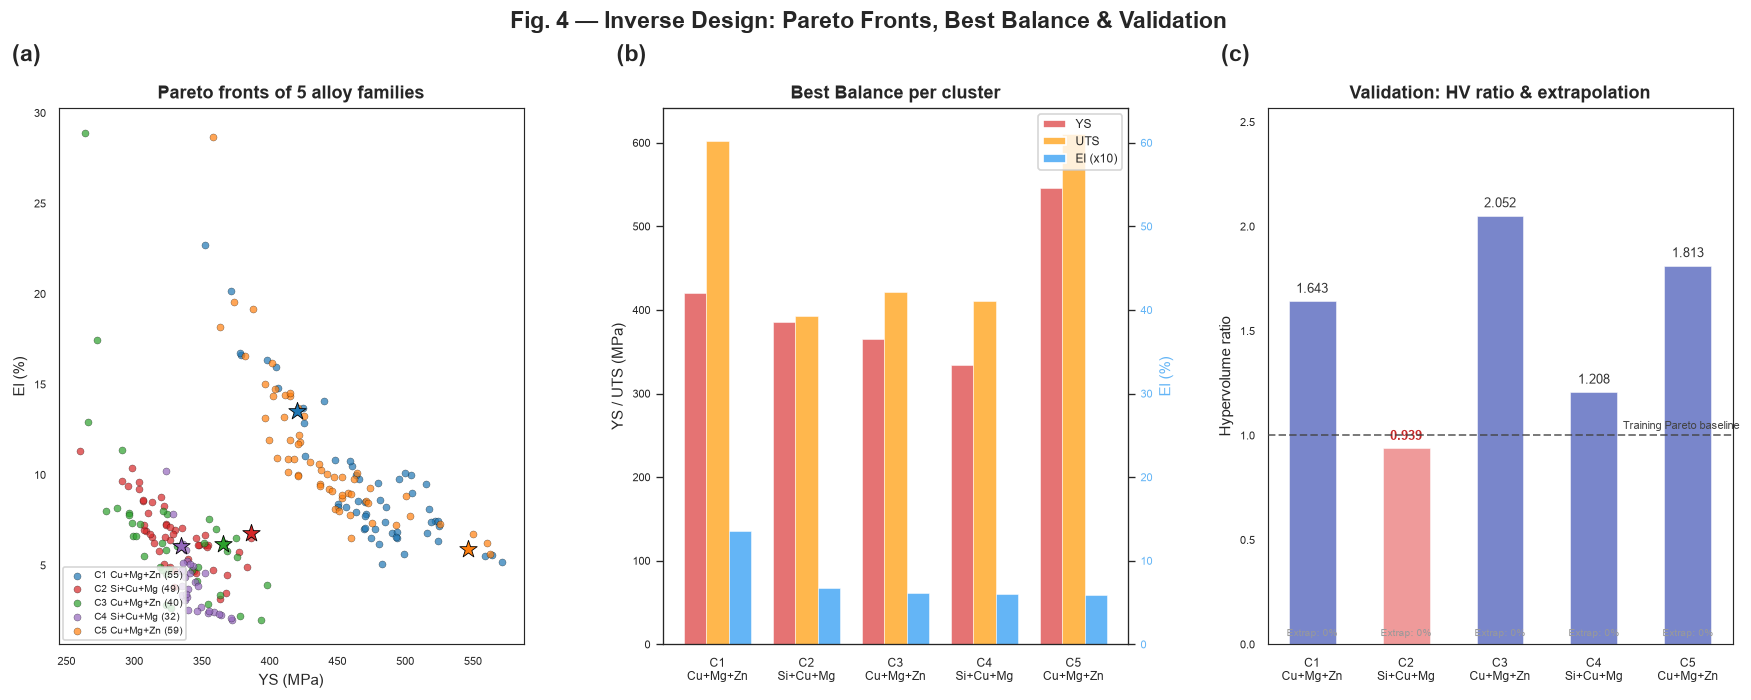

Figure 4 saved.


In [19]:
# ── Load data ──
df_pareto = pd.read_csv(os.path.join(OPT_DIR, 'cluster_pareto.csv'))
df_train  = pd.read_csv(os.path.join(OPT_DIR, 'training_clustered.csv'))

if 'cluster_id' in df_pareto.columns:
    df_pareto['cid'] = df_pareto['cluster_id']
else:
    df_pareto['cid'] = df_pareto['cluster'] + 1

colors5 = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e']

# ── Cluster info ──
cluster_info = {}
for c in sorted(df_train['cluster'].unique()):
    mask = df_train['cluster'] == c
    cdf = df_train[mask]
    sig = [e for e in ELEMENTS if cdf[e].mean() > 0.005]
    label = '+'.join(sig[:3]) if sig else f'C{c+1}'
    cluster_info[c] = {'label': label, 'n': mask.sum(), 'id': c+1}

# ── Pareto & HV functions (from N08) ──
def pareto_2d(ys, el):
    valid = ~(np.isnan(ys) | np.isnan(el))
    if not valid.all(): ys, el = ys[valid], el[valid]
    costs = np.column_stack([-ys, -el]); n = costs.shape[0]
    eff = np.ones(n, dtype=bool)
    for i in range(n):
        if not eff[i]: continue
        dominated = (np.all(costs[eff] <= costs[i], axis=1) & np.any(costs[eff] < costs[i], axis=1))
        eff[eff] = ~dominated; eff[i] = True
    return eff

def hypervolume_2d(ys, el, ref_ys, ref_el):
    valid = ~(np.isnan(ys) | np.isnan(el))
    ys, el = ys[valid], el[valid]
    if len(ys) == 0: return 0.0
    idx = np.argsort(ys); ys_s, el_s = ys[idx], el[idx]
    keep = np.ones(len(ys_s), dtype=bool); best_el = -np.inf
    for i in range(len(ys_s)-1, -1, -1):
        if el_s[i] <= best_el: keep[i] = False
        else: best_el = el_s[i]
    ys_s, el_s = ys_s[keep], el_s[keep]
    hv = 0.0; prev_ys = ref_ys
    for i in range(len(ys_s)):
        if ys_s[i] > prev_ys and el_s[i] > ref_el:
            hv += (ys_s[i] - prev_ys) * (el_s[i] - ref_el); prev_ys = ys_s[i]
    return max(hv, 0.0)

# ── Compute per-cluster metrics ──
ref_ys = df_train.loc[df_train[['YS','UTS','El']].notna().all(axis=1), 'YS'].min() - 10
ref_el = df_train.loc[df_train[['YS','UTS','El']].notna().all(axis=1), 'El'].min() - 1

cluster_metrics = []
for c_idx in sorted(cluster_info.keys()):
    info = cluster_info[c_idx]
    sdf = df_pareto[df_pareto['cid'] == info['id']]
    ys_p = sdf['YS_pred'].values; uts_p = sdf['UTS_pred'].values; el_p = sdf['El_pred'].values

    utopia = np.array([ys_p.max(), uts_p.max(), el_p.max()])
    nadir = np.array([ys_p.min(), uts_p.min(), el_p.min()])
    rng = np.where(utopia - nadir > 1e-6, utopia - nadir, 1.0)
    dist = np.sqrt(np.sum(((utopia - np.column_stack([ys_p, uts_p, el_p])) / rng)**2, axis=1))
    bb = sdf.iloc[np.argmin(dist)]

    train_mask = (df_train['cluster'] == c_idx) & df_train[['YS','UTS','El']].notna().all(axis=1)
    train_ys = df_train.loc[train_mask, 'YS'].values.astype(float)
    train_el = df_train.loc[train_mask, 'El'].values.astype(float)
    train_p2 = pareto_2d(train_ys, train_el)
    hv_train = hypervolume_2d(train_ys[train_p2], train_el[train_p2], ref_ys, ref_el)
    hv_pred  = hypervolume_2d(ys_p, el_p, ref_ys, ref_el)
    hv_ratio = hv_pred / hv_train if hv_train > 0 else float('nan')

    train_comp = df_train.loc[train_mask, ELEMENTS].fillna(0).values
    pred_comp = sdf[ELEMENTS].fillna(0).values
    if len(pred_comp) > 0 and len(train_comp) >= 3:
        nn_dists = cdist(pred_comp, train_comp, metric='euclidean').min(axis=1)
        thr_95 = np.percentile(pdist(train_comp, metric='euclidean'), 95)
        extrap_pct = 100.0 * (nn_dists > thr_95).sum() / len(nn_dists)
    else:
        extrap_pct = 0.0

    cluster_metrics.append({
        'cid': info['id'], 'label': info['label'], 'n': info['n'],
        'n_pareto': len(sdf), 'bb_ys': bb['YS_pred'], 'bb_uts': bb['UTS_pred'],
        'bb_el': bb['El_pred'], 'hv_ratio': hv_ratio, 'extrap_pct': extrap_pct,
    })

# ═══════════════════════════════════════════════
# Color palette
C_YS_BAR  = '#E57373'   # soft red
C_UTS_BAR = '#FFB74D'   # soft amber
C_EL_BAR  = '#64B5F6'   # soft blue
C_HV_PASS = '#7986CB'   # soft indigo (HV >= 1)
C_HV_FAIL = '#EF9A9A'   # soft pink-red (HV < 1)

fig = plt.figure(figsize=(18, 5.8))

# ── (a) All-cluster Pareto overlay ──
ax = fig.add_subplot(1, 3, 1)
for ci, c in enumerate(sorted(df_pareto['cid'].unique())):
    sdf = df_pareto[df_pareto['cid'] == c]
    lbl = f'C{c} {sdf["cluster_label"].iloc[0]} ({len(sdf)})'
    ax.scatter(sdf['YS_pred'], sdf['El_pred'], c=colors5[ci], s=18, alpha=0.7,
              edgecolors='k', linewidth=0.2, label=lbl)
    cm = cluster_metrics[ci]
    ax.scatter(cm['bb_ys'], cm['bb_el'], marker='*', s=120, c=colors5[ci],
              edgecolors='k', linewidth=0.5, zorder=10)

ax.set_xlabel('YS (MPa)', fontsize=9)
ax.set_ylabel('El (%)', fontsize=9)
ax.set_title('Pareto fronts of 5 alloy families', fontsize=11, fontweight='bold')
ax.legend(fontsize=5.8, loc='lower left', ncol=1, framealpha=0.8)
add_label(ax, '(a)')

# ── (b) Best Balance comparison ──
ax = fig.add_subplot(1, 3, 2)
x = np.arange(len(cluster_metrics)); w = 0.25
for i, cm in enumerate(cluster_metrics):
    ax.bar(i - w, cm['bb_ys'], w, color=C_YS_BAR, edgecolor='white', linewidth=0.3)
    ax.bar(i,      cm['bb_uts'], w, color=C_UTS_BAR, edgecolor='white', linewidth=0.3)
    ax.bar(i + w,  cm['bb_el'] * 10, w, color=C_EL_BAR, edgecolor='white', linewidth=0.3)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim()[0] / 10, ax.get_ylim()[1] / 10)
ax2.set_ylabel('El (%)', fontsize=9, color=C_EL_BAR)
ax2.tick_params(axis='y', labelcolor=C_EL_BAR)

ax.set_xticks(x)
ax.set_xticklabels([f'C{cm["cid"]}\n{cm["label"]}' for cm in cluster_metrics], fontsize=7)
ax.set_ylabel('YS / UTS (MPa)', fontsize=9)
ax.set_title('Best Balance per cluster', fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=C_YS_BAR, label='YS'),
    Patch(facecolor=C_UTS_BAR, label='UTS'),
    Patch(facecolor=C_EL_BAR, label='El (x10)'),
], fontsize=7, loc='upper right', framealpha=0.8)
add_label(ax, '(b)')

# ── (c) Validation: HV ratio ──
ax = fig.add_subplot(1, 3, 3)
x = np.arange(len(cluster_metrics)); w = 0.50
hv_ratios = [cm['hv_ratio'] for cm in cluster_metrics]
extrap_pcts = [cm['extrap_pct'] for cm in cluster_metrics]

bar_colors = [C_HV_PASS if hv >= 1.0 else C_HV_FAIL for hv in hv_ratios]
bars = ax.bar(x, hv_ratios, w, color=bar_colors, edgecolor='white', linewidth=0.3)

ax.axhline(y=1.0, color='#444444', lw=1.2, ls='--', alpha=0.7, zorder=5)
ax.text(len(x)-0.45, 1.02, 'Training Pareto baseline', fontsize=6.5, color='#444444',
        ha='right', va='bottom')

for bar, hv in zip(bars, hv_ratios):
    color = '#333333' if hv >= 1.0 else '#C62828'
    fw = 'bold' if hv < 1.0 else 'normal'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{hv:.3f}', ha='center', fontsize=7.5, color=color, fontweight=fw)

for bar, ep in zip(bars, extrap_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, 0.04, f'Extrap: {ep:.0f}%',
            ha='center', fontsize=6, color='#999999')

ax.set_xticks(x)
ax.set_xticklabels([f'C{cm["cid"]}\n{cm["label"]}' for cm in cluster_metrics], fontsize=7)
ax.set_ylabel('Hypervolume ratio', fontsize=9)
ax.set_title('Validation: HV ratio & extrapolation', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(hv_ratios) * 1.25)
ax.yaxis.set_minor_locator(AutoMinorLocator())
add_label(ax, '(c)')

fig.suptitle('Fig. 4 — Inverse Design: Pareto Fronts, Best Balance & Validation',
             fontsize=14, y=1.02, fontweight='bold')
plt.subplots_adjust(wspace=0.30)
save_fig(fig, 'Fig4_Inverse_Design')
plt.show()
print('Figure 4 saved.')

## Pipeline Complete

All figures saved to `../figure/`:

| Figure | File | Panels |
|--------|------|--------|
| Graphical Abstract | `Graphical_Abstract.pdf` | 1 |
| Fig 1: EDA | `Fig1_EDA_PairGrid.pdf` | 20x20 PairGrid |
| Fig 2: Model Comparison | `Fig2_Model_Comparison.pdf` | 6 (2 rows x 3 cols) |
| Fig 3: SHAP | `Fig3_SHAP.pdf` | 6 (2 rows x 3 cols) |
| Fig 4: Inverse Design | `Fig4_Inverse_Design.pdf` | 3 (1 row x 3 cols) |